# Automated Customer Reviews — Classification, Clustering & Generative AI Summarization

**Project | Business Case: Automated Customer Reviews**

This notebook implements the 3 main tasks :

***Sentiment CLASSIFICATION** — classify each review as *positive / negative / neutral* based on the star rating, then with a pretrained Transformer model.

***Product category CLUSTERING** — group products into 4 to 6 meta-categories.

***Generative AI SUMMARIZATION** — generate a short article (blog-post style) per meta-category, with the top 3 products, their main complaints, and the worst product to avoid.

The notebook ends with an interactive demo (deployment bonus) built with #############.

> **Team:** Lydia, Marcelo, Don.

> **Date:** 15_06_2026

**ROADMAP**

1. DATASET ACQUISITION

2. DATA UNDERSTANDING

3. CLEANING
4. LABEL CREATION
5. EDA
6. BALANCING
7. BASELINE MODEL : Classification sentiments with pretrained transformer model on HF.
8. COMPARISON MODEL
9. EVALUATION
10. CLUSTERING : create categories products with KMeans
11. SUMMARIZATION : generate short articles summarization with generative AI
12. APP
13. REPORT + DERIVABLES


**1.DATASET ACQUISITION**

1.1 Import libraries

1.2 Data loadind

In [18]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn transformers datasets evaluate accelerate sentence-transformers gradio torch kaggle

In [19]:
import os
import re
import glob
import json
import gzip
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)

from sentence_transformers import SentenceTransformer
import gradio as gr

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


1.3 Project Configuration

This section defines all project paths and execution options.

In [20]:
# ============================================================
# Paths
# ============================================================
DATA_DIR = "data"
PRIMARY_DIR = os.path.join(DATA_DIR, "primary")
LARGER_DIR = os.path.join(DATA_DIR, "larger")
OUTPUT_DIR = "outputs"

os.makedirs(PRIMARY_DIR, exist_ok=True)
os.makedirs(LARGER_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# Dataset limits
# ============================================================
MAX_PRIMARY_ROWS = None          # None = use all available primary rows
MAX_LARGER_ROWS = 100000          # UCSD is huge. Start small.
MAX_BALANCED_PER_CLASS = 10000    # Increase if Colab GPU can handle it
MAX_CLUSTER_ROWS = 5000

# ============================================================
# Model configuration
# ============================================================
BASELINE_MODEL_NAME = "distilbert-base-uncased"
COMPARISON_MODEL_NAME = "roberta-base"
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
SUMMARIZER_MODEL_NAME = "facebook/bart-large-cnn"

RUN_TRAINING = True
RUN_COMPARISON_MODEL = True
RUN_SPECIALIST_MODELS = False    # Set True only if you have enough time/GPU
RUN_GRADIO_APP = True

# Training parameters
NUM_EPOCHS = 2
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
MAX_TOKEN_LENGTH = 256

**2. DATA UNDERSTANDING**

The project requires two datasets.

### Primary dataset — Kaggle

The primary dataset is available on Kaggle. Since Kaggle requires authentication, and we have to download it.

### Larger dataset — UCSD Amazon Reviews



In [21]:
# ============================================================
# PRIMARY DATASET
# ============================================================

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d datafiniti/consumer-reviews-of-amazon-products -p data/primary --unzip

# After download, the primary CSV should appear inside data/primary/

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/datafiniti/consumer-reviews-of-amazon-products
License(s): CC-BY-NC-SA-4.0
100% 16.3M/16.3M [00:00<00:00, 167MB/s]



In [22]:
import pandas as pd

df_primary = pd.read_csv("data/primary/1429_1.csv")

print(df_primary.shape)
df_primary.head(10)

(34660, 21)


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42
5,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This amazon fire 8 inch tablet is the perfect ...,Just what we expected,NaN,NaN,tklit
6,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,"Great for e-reading on the go, nice and light ...",great e-reader tablet,NaN,NaN,Droi
7,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,"I gave this as a Christmas gift to my inlaws, ...",Great for gifts,NaN,NaN,Kacy
8,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",

In [23]:
df_primary.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')

In [24]:
############______________________################

# LARGER DATASET

############______________________################


import os
import json
import gzip
import requests
import pandas as pd
from tqdm import tqdm

LARGER_DIR = "data/larger"
os.makedirs(LARGER_DIR, exist_ok=True)

SAMPLE_PER_CATEGORY = 10000

BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories"

CATEGORIES = [
    "All_Beauty",
    "Amazon_Fashion",
    "Appliances",
    "Arts_Crafts_and_Sewing",
    "Automotive",
    "Baby_Products",
    "Beauty_and_Personal_Care",
    "Books",
    "CDs_and_Vinyl",
    "Cell_Phones_and_Accessories",
    "Clothing_Shoes_and_Jewelry",
    "Digital_Music",
    "Electronics",
    "Gift_Cards",
    "Grocery_and_Gourmet_Food",
    "Handmade_Products",
    "Health_and_Household",
    "Health_and_Personal_Care",
    "Home_and_Kitchen",
    "Industrial_and_Scientific",
    "Kindle_Store",
    "Magazine_Subscriptions",
    "Movies_and_TV",
    "Musical_Instruments",
    "Office_Products",
    "Patio_Lawn_and_Garden",
    "Pet_Supplies",
    "Software",
    "Sports_and_Outdoors",
    "Subscription_Boxes",
    "Tools_and_Home_Improvement",
    "Toys_and_Games",
    "Video_Games"
]

def map_rating_to_sentiment(rating):
    rating = float(rating)
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

def stream_category_sample(category, sample_size=10000):
    url = f"{BASE_URL}/{category}.jsonl.gz"
    rows = []

    print(f"\nStreaming category: {category}")
    print(url)

    try:
        response = requests.get(url, stream=True, timeout=60)
        response.raise_for_status()

        with gzip.GzipFile(fileobj=response.raw) as gz:
            for line in tqdm(gz, desc=category):
                if len(rows) >= sample_size:
                    break

                try:
                    item = json.loads(line.decode("utf-8"))
                except Exception:
                    continue

                text = item.get("text", "")
                title = item.get("title", "")
                rating = item.get("rating", None)

                if not text or rating is None:
                    continue

                review_text = f"{title}. {text}" if title else text

                rows.append({
                    "review_text": review_text,
                    "rating": float(rating),
                    "sentiment": map_rating_to_sentiment(rating),
                    "product_name": item.get("parent_asin", item.get("asin", "Unknown Product")),
                    "raw_category": category,
                    "source": "amazon_reviews_2023"
                })

    except Exception as e:
        print(f"[ERROR] Failed category {category}: {e}")

    return pd.DataFrame(rows)

all_dfs = []

for category in CATEGORIES:
    category_df = stream_category_sample(category, SAMPLE_PER_CATEGORY)

    print(f"{category}: {category_df.shape[0]} reviews collected")

    if not category_df.empty:
        all_dfs.append(category_df)

larger_df = pd.concat(all_dfs, ignore_index=True)

larger_df = larger_df.dropna(subset=["review_text", "rating", "sentiment"])
larger_df = larger_df.drop_duplicates(subset=["review_text"])

output_path = f"{LARGER_DIR}/amazon_reviews_2023_all_categories_sampled.csv"
larger_df.to_csv(output_path, index=False)

print("\nFINAL SHAPE:", larger_df.shape)
print("Saved to:", output_path)

display(larger_df.head())
display(larger_df["raw_category"].value_counts())
display(larger_df["sentiment"].value_counts())


Streaming category: All_Beauty
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz


All_Beauty: 10000it [00:00, 25813.96it/s]


All_Beauty: 10000 reviews collected

Streaming category: Amazon_Fashion
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Amazon_Fashion.jsonl.gz


Amazon_Fashion: 10000it [00:00, 25698.17it/s]


Amazon_Fashion: 10000 reviews collected

Streaming category: Appliances
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Appliances.jsonl.gz


...

Video_Games: 10000it [00:00, 19354.79it/s]


Video_Games: 10000 reviews collected

FINAL SHAPE: (317201, 6)
Saved to: data/larger/amazon_reviews_2023_all_categories_sampled.csv


,review_text,rating,sentiment,product_name,raw_category,source
0,Such a lovely scent but not overpowering.. Thi...,5.0,positive,B00YQ6X8EO,All_Beauty,amazon_reviews_2023
1,Works great but smells a little weird.. This p...,4.0,positive,B081TJ8YS3,All_Beauty,amazon_reviews_2023
2,"Yes!. Smells good, feels great!",5.0,positive,B097R46CSY,All_Beauty,amazon_reviews_2023
3,Synthetic feeling. Felt synthetic,1.0,negative,B09JS339BZ,All_Beauty,amazon_reviews_2023
4,A+. Love it,5.0,positive,B08BZ63GMJ,All_Beauty,amazon_reviews_2023


,count
raw_category,
All_Beauty,9905
Subscription_Boxes,9876
Kindle_Store,9860
Amazon_Fashion,9859
Beauty_and_Personal_Care,9830
Appliances,9781
Books,9777
Handmade_Products,9749
Musical_Instruments,9746


,count
sentiment,
positive,258775
negative,33851
neutral,24575


In [25]:
larger_df = pd.read_csv("data/larger/amazon_reviews_2023_all_categories_sampled.csv")

print(larger_df.shape)
larger_df.head()

(317201, 6)


,review_text,rating,sentiment,product_name,raw_category,source
0,Such a lovely scent but not overpowering.. Thi...,5.0,positive,B00YQ6X8EO,All_Beauty,amazon_reviews_2023
1,Works great but smells a little weird.. This p...,4.0,positive,B081TJ8YS3,All_Beauty,amazon_reviews_2023
2,"Yes!. Smells good, feels great!",5.0,positive,B097R46CSY,All_Beauty,amazon_reviews_2023
3,Synthetic feeling. Felt synthetic,1.0,negative,B09JS339BZ,All_Beauty,amazon_reviews_2023
4,A+. Love it,5.0,positive,B08BZ63GMJ,All_Beauty,amazon_reviews_2023


**3. CLEANING**

In this section we define some helper and reusable functions for:

- Cleaning review text.
- Mapping star ratings to sentiment labels.
- Loading the primary Kaggle dataset.
- Loading the larger UCSD dataset.
- Balancing the dataset.
- Training Hugging Face models.
- Plotting evaluation results.

The rating-to-sentiment mapping follows the project brief:

| Star rating | Sentiment |
|---|---|
| 1–2 | Negative |
| 3 | Neutral |
| 4–5 | Positive |

In [26]:
def clean_text(text):
    """Basic text cleaning for review text. It preserves normal word spacing."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r'[^A-Za-z0-9À-ÿ.,!?;:"()€$%&/\-\s]', " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def map_rating_to_sentiment(rating):
    """Maps 1-5 star ratings into the 3 required sentiment classes."""
    try:
        rating = float(rating)
    except Exception:
        return np.nan

    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    elif rating >= 4:
        return "positive"
    return np.nan


label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}


def normalize_product_name(x):
    """
    Cleans product names while preserving readable spacing.

    Important:
    - Kaggle/Datafiniti often gives real product names.
    - Amazon Reviews 2023 review files often give ASINs instead of real names.
      We do not pretend those ASINs are product names.
    """
    if pd.isna(x):
        return "Unknown Product"

    x = str(x)
    x = x.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    x = re.sub(r",+", ",", x)
    x = re.sub(r"\s*,\s*", ", ", x)      # comma followed by a space
    x = re.sub(r"\s*-\s*", " - ", x)      # readable hyphen separation
    x = re.sub(r"\s+", " ", x)
    x = x.strip(" ,-")

    if len(x) == 0 or x.lower() in {"nan", "none", "null"}:
        return "Unknown Product"
    return x


def is_asin(x):
    """Detects Amazon ASIN-like product identifiers."""
    return bool(re.fullmatch(r"B[0-9A-Z]{9}", str(x).strip()))


def product_id_type(x):
    """Classifies a product identifier as named product, ASIN, or unknown."""
    x = normalize_product_name(x)
    if x == "Unknown Product":
        return "unknown"
    if is_asin(x):
        return "asin"
    return "named_product"


def normalize_category(x):
    """
    Normalizes category values.

    - Kaggle/Datafiniti often has comma-separated category paths.
      We keep only the first level, e.g. 'Electronics,iPad & Tablets' -> 'Electronics'.
    - Amazon Reviews 2023 already has one category name, e.g. 'Books'.
    """
    if pd.isna(x):
        return "Unknown Category"

    x = str(x)
    x = x.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    x = x.replace("[", "").replace("]", "")
    x = x.replace("{", "").replace("}", "")
    x = x.replace("'", "").replace('"', "")
    x = re.sub(r"\s+", " ", x).strip()

    if "," in x:
        x = x.split(",")[0].strip()

    if len(x) == 0 or x.lower() in {"nan", "none", "null"}:
        return "Unknown Category"
    return x


def make_product_display_name(product_name, raw_category):
    """
    Creates a safe display name for EDA and reports.

    Real names are preserved.
    ASIN-only products are shown as category products with the ASIN in parentheses.
    Unknown products remain explicit and can be excluded from product-level charts.
    """
    product_name = normalize_product_name(product_name)
    category = normalize_category(raw_category)

    if product_name == "Unknown Product":
        return "Unknown Product"
    if is_asin(product_name):
        return f"{category} product ({product_name})"
    return product_name


def shorten_label(x, max_len=70):
    """Shortens very long labels for readable plots/tables."""
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 3] + "..."


def find_first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def stratified_limit_by_category(dataframe, max_rows, category_col="raw_category"):
    """
    Limits a large dataset while preserving category diversity.

    Do not use plain .head(max_rows) here: the Amazon Reviews 2023 sampled CSV may be
    ordered by category, so .head() can silently keep only the first few categories.
    """
    if max_rows is None or len(dataframe) <= max_rows:
        return dataframe.copy().reset_index(drop=True)

    if category_col not in dataframe.columns:
        return dataframe.sample(max_rows, random_state=RANDOM_STATE).reset_index(drop=True)

    n_categories = dataframe[category_col].nunique()
    per_category = max(1, int(np.ceil(max_rows / n_categories)))

    sampled = (
        dataframe
        .groupby(category_col, group_keys=False)
        .apply(lambda x: x.sample(min(len(x), per_category), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )

    if len(sampled) > max_rows:
        sampled = sampled.sample(max_rows, random_state=RANDOM_STATE).reset_index(drop=True)

    return sampled

In [27]:
def load_primary_dataset(primary_dir):
    """Loads the Kaggle/Datafiniti primary dataset and converts it to the unified schema."""
    files = []
    files.extend(glob.glob(os.path.join(primary_dir, "*.csv")))
    files.extend(glob.glob(os.path.join(primary_dir, "*.tsv")))

    if len(files) == 0:
        print(f"[WARNING] No primary dataset file found in {primary_dir}")
        return pd.DataFrame()

    parts = []

    for file in files:
        print("Loading primary file:", file)

        if file.endswith(".tsv"):
            temp = pd.read_csv(file, sep="\t", low_memory=False)
        else:
            temp = pd.read_csv(file, low_memory=False)

        if MAX_PRIMARY_ROWS is not None:
            temp = temp.sample(min(MAX_PRIMARY_ROWS, len(temp)), random_state=RANDOM_STATE)

        text_col = find_first_existing_column(temp, [
            "reviews.text", "review_text", "text", "reviewText", "reviews"
        ])
        rating_col = find_first_existing_column(temp, [
            "reviews.rating", "rating", "overall", "stars", "reviews.stars"
        ])
        product_col = find_first_existing_column(temp, [
            "name", "product_name", "title", "asins", "asin"
        ])
        category_col = find_first_existing_column(temp, [
            "categories", "primaryCategories", "category", "main_cat"
        ])

        if text_col is None or rating_col is None:
            print("[WARNING] Skipping file because text/rating columns were not found:", file)
            print("Available columns:", temp.columns.tolist())
            continue

        part = pd.DataFrame()
        part["review_text"] = temp[text_col].apply(clean_text)
        part["rating"] = pd.to_numeric(temp[rating_col], errors="coerce")
        part["product_name"] = temp[product_col].apply(normalize_product_name) if product_col else "Unknown Product"
        part["raw_category"] = temp[category_col].apply(normalize_category) if category_col else "Unknown Category"
        part["source"] = "primary"
        parts.append(part)

    if len(parts) == 0:
        return pd.DataFrame()

    return pd.concat(parts, ignore_index=True)


def load_larger_ucsd_dataset(folder, max_rows=None):
    """
    Loads the larger Amazon Reviews 2023 / UCSD-style dataset.

    Supported files in data/larger/:
    - sampled CSV created by the helper cell
    - .jsonl.gz / .json.gz / .json line files

    Important fix:
    For CSV files, we do stratified sampling by category instead of .head(max_rows),
    otherwise the first categories in the file dominate the larger dataset.
    """
    frames = []

    if not os.path.exists(folder):
        print(f"[WARNING] Larger dataset folder not found: {folder}")
        return pd.DataFrame()

    csv_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".csv")]

    for path in csv_files:
        print(f"Loading larger CSV file: {path}")
        temp = pd.read_csv(path, low_memory=False)

        required_cols = ["review_text", "rating", "product_name", "raw_category", "source"]
        if not all(col in temp.columns for col in required_cols):
            raise ValueError(f"CSV file {path} does not have the expected schema: {required_cols}")

        temp = temp[required_cols].copy()
        temp["review_text"] = temp["review_text"].apply(clean_text)
        temp["rating"] = pd.to_numeric(temp["rating"], errors="coerce")
        temp["product_name"] = temp["product_name"].apply(normalize_product_name)
        temp["raw_category"] = temp["raw_category"].apply(normalize_category)
        temp["source"] = temp["source"].fillna("amazon_reviews_2023")

        temp = stratified_limit_by_category(temp, max_rows=max_rows, category_col="raw_category")
        frames.append(temp)

    json_files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".json") or f.endswith(".json.gz") or f.endswith(".jsonl.gz")
    ]

    for path in json_files:
        print(f"Loading larger JSON file: {path}")
        rows = []
        opener = gzip.open if path.endswith(".gz") else open
        category_from_file = os.path.basename(path).replace(".jsonl.gz", "").replace(".json.gz", "").replace(".json", "")

        with opener(path, "rt", encoding="utf-8") as f:
            for line in f:
                if max_rows is not None and len(rows) >= max_rows:
                    break
                try:
                    item = json.loads(line)
                except Exception:
                    continue

                text = item.get("text", item.get("reviewText", ""))
                title = item.get("title", item.get("summary", ""))
                rating = item.get("rating", item.get("overall", None))

                if not text or rating is None:
                    continue

                review_text = f"{title}. {text}" if title else text
                rows.append({
                    "review_text": clean_text(review_text),
                    "rating": float(rating),
                    "product_name": normalize_product_name(item.get("parent_asin", item.get("asin", "Unknown Product"))),
                    "raw_category": normalize_category(category_from_file),
                    "source": "amazon_reviews_2023"
                })

        if rows:
            temp = pd.DataFrame(rows)
            temp = stratified_limit_by_category(temp, max_rows=max_rows, category_col="raw_category")
            frames.append(temp)

    if not frames:
        print(f"[WARNING] No larger dataset file found in {folder}")
        return pd.DataFrame()

    larger_df = pd.concat(frames, ignore_index=True)
    print("Loaded larger dataset shape:", larger_df.shape)
    return larger_df

In [28]:
def balance_dataset(df, max_per_class=3000):
    """
    Downsamples each sentiment class to the same maximum size.

    This is necessary because Amazon reviews are usually highly positive-heavy.
    Without balancing, a model can achieve misleading accuracy by mostly predicting positive.
    """
    balanced_parts = []

    for sentiment in ["negative", "neutral", "positive"]:
        part = df[df["sentiment"] == sentiment]
        n = min(len(part), max_per_class)

        if n == 0:
            print(f"[WARNING] No rows for class: {sentiment}")
            continue

        balanced_parts.append(part.sample(n, random_state=RANDOM_STATE))

    balanced = pd.concat(balanced_parts, ignore_index=True)
    balanced = balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    return balanced


def plot_count(series, title, xlabel):
    plt.figure(figsize=(8, 4))
    order = series.value_counts().index
    sns.countplot(x=series, order=order)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title):
    labels = [0, 1, 2]
    label_names = ["negative", "neutral", "positive"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=label_names,
        yticklabels=label_names
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [29]:
def tokenize_for_transformer(train_df, test_df, model_name, max_length=256):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = Dataset.from_pandas(train_df[["review_text", "label"]])
    test_dataset = Dataset.from_pandas(test_df[["review_text", "label"]])

    def tokenize(batch):
        return tokenizer(
            batch["review_text"],
            padding="max_length",
            truncation=True,
            max_length=max_length
        )

    train_dataset = train_dataset.map(tokenize, batched=True)
    test_dataset = test_dataset.map(tokenize, batched=True)

    train_dataset = train_dataset.remove_columns(["review_text"])
    test_dataset = test_dataset.remove_columns(["review_text"])

    train_dataset.set_format("torch")
    test_dataset.set_format("torch")

    return tokenizer, train_dataset, test_dataset


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }


def train_transformer_classifier(
    train_df,
    test_df,
    model_name,
    output_subdir,
    epochs=2,
    batch_size=8,
    learning_rate=2e-5
):
    """
    Fine-tunes a Hugging Face Transformer model for 3-class sentiment classification.
    """
    print("\nTraining model:", model_name)

    tokenizer, train_dataset, test_dataset = tokenize_for_transformer(
        train_df,
        test_df,
        model_name=model_name,
        max_length=MAX_TOKEN_LENGTH
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    )

    output_path = os.path.join(OUTPUT_DIR, output_subdir)

    args = TrainingArguments(
        output_dir=output_path,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="none",
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = test_df["label"].values

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"]))

    plot_confusion_matrix(y_true, y_pred, f"Confusion Matrix - {model_name}")

    trainer.save_model(output_path)
    tokenizer.save_pretrained(output_path)

    return {
        "model_name": model_name,
        "output_path": output_path,
        "trainer": trainer,
        "tokenizer": tokenizer,
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    }

In [30]:
def train_specialist_binary_model(
    train_df,
    test_df,
    target_sentiment,
    base_model_name="distilbert-base-uncased",
    epochs=1,
    batch_size=8
):
    """
    Trains a one-vs-rest specialist model.

    Examples:
    - positive specialist: positive vs not_positive
    - negative specialist: negative vs not_negative
    - neutral specialist: neutral vs not_neutral

    This is optional and computationally heavier.
    """
    print(f"\nTraining specialist model for: {target_sentiment}")

    temp_train = train_df.copy()
    temp_test = test_df.copy()

    temp_train["label"] = (temp_train["sentiment"] == target_sentiment).astype(int)
    temp_test["label"] = (temp_test["sentiment"] == target_sentiment).astype(int)

    tokenizer = AutoTokenizer.from_pretrained(base_model_name)

    train_dataset = Dataset.from_pandas(temp_train[["review_text", "label"]])
    test_dataset = Dataset.from_pandas(temp_test[["review_text", "label"]])

    def tokenize(batch):
        return tokenizer(
            batch["review_text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_TOKEN_LENGTH
        )

    train_dataset = train_dataset.map(tokenize, batched=True)
    test_dataset = test_dataset.map(tokenize, batched=True)

    train_dataset = train_dataset.remove_columns(["review_text"])
    test_dataset = test_dataset.remove_columns(["review_text"])

    train_dataset.set_format("torch")
    test_dataset.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        base_model_name,
        num_labels=2,
        id2label={0: f"not_{target_sentiment}", 1: target_sentiment},
        label2id={f"not_{target_sentiment}": 0, target_sentiment: 1}
    )

    output_path = os.path.join(OUTPUT_DIR, f"specialist_{target_sentiment}")

    def binary_compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "weighted_f1": f1_score(labels, preds, average="weighted")
        }

    args = TrainingArguments(
        output_dir=output_path,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="weighted_f1",
        greater_is_better=True,
        report_to="none",
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer,
        compute_metrics=binary_compute_metrics
    )

    trainer.train()
    trainer.save_model(output_path)
    tokenizer.save_pretrained(output_path)

    return {
        "sentiment": target_sentiment,
        "output_path": output_path,
        "trainer": trainer,
        "tokenizer": tokenizer
    }

**4. LOAD AND MERGE THE TWO DATASETS**

This section loads:

1. The primary Kaggle/Datafiniti dataset.
2. The larger UCSD Amazon Reviews dataset.

Both datasets are merged into a unified schema, that is required before performing EDA and training the model.

In [31]:
primary_df = load_primary_dataset(PRIMARY_DIR)
larger_df = load_larger_ucsd_dataset(LARGER_DIR, max_rows=MAX_LARGER_ROWS)

print("Primary dataset shape:", primary_df.shape)
print("Larger dataset shape:", larger_df.shape)

df = pd.concat([primary_df, larger_df], ignore_index=True)

if df.empty:
    raise ValueError(
        """
        No data was loaded.

        Next step:
        - Download the Kaggle primary CSV into data/primary/
        - Upload at least one UCSD .json.gz file into data/larger/
        """
    )

print("Merged raw shape:", df.shape)
df.head()

Loading primary file: data/primary/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv
Loading primary file: data/primary/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
Loading primary file: data/primary/1429_1.csv
Loading larger CSV file: data/larger/amazon_reviews_2023_all_categories_sampled.csv
Loaded larger dataset shape: (100000, 5)
Primary dataset shape: (67992, 5)
Larger dataset shape: (100000, 5)
Merged raw shape: (167992, 5)


,review_text,rating,product_name,raw_category,source
0,I order 3 of them and one of the item is bad q...,3.0,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary
1,Bulk is always the less expensive way to go fo...,4.0,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary
2,Well they are not Duracell but for the price i...,5.0,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary
3,Seem to work as well as name brand batteries a...,5.0,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary
4,These batteries are very long lasting the pric...,5.0,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary


## 5. Data Cleaning and Sentiment Label Creation

This section cleans the merged dataset and creates the target variable.

The model does not directly learn from the star rating. The star rating is only used to create the supervised label:

- 1–2 stars → `negative`
- 3 stars → `neutral`
- 4–5 stars → `positive`

Rows with missing rating, missing review text, very short reviews, or duplicate review text are removed.

In [32]:
# ============================================================
# Cleaning, label creation, and safe product display columns
# ============================================================

df["review_text"] = df["review_text"].apply(clean_text)
df["product_name"] = df["product_name"].apply(normalize_product_name)
df["raw_category"] = df["raw_category"].apply(normalize_category)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Remove rows that cannot support supervised learning.
df = df.dropna(subset=["rating", "review_text"])
df = df[df["review_text"].str.len() >= 10]

# Create supervised target from rating.
df["sentiment"] = df["rating"].apply(map_rating_to_sentiment)
df = df.dropna(subset=["sentiment"])
df["label"] = df["sentiment"].map(label2id).astype(int)

# Product identifier quality fields.
df["product_id_type"] = df["product_name"].apply(product_id_type)
df["product_display_name"] = df.apply(
    lambda row: make_product_display_name(row["product_name"], row["raw_category"]),
    axis=1
)
df["product_display_short"] = df["product_display_name"].apply(lambda x: shorten_label(x, 75))

# Remove exact duplicated review/product/rating rows.
df = df.drop_duplicates(subset=["review_text", "rating", "product_name"])
df = df.reset_index(drop=True)

print("Clean merged dataset shape:", df.shape)
print("Product identifier quality:")
display(df["product_id_type"].value_counts().to_frame("count"))

display(df[[
    "review_text", "rating", "product_name", "product_id_type",
    "product_display_name", "raw_category", "source", "sentiment", "label"
]].head())

Clean merged dataset shape: (163282, 10)
Product identifier quality:


,count
product_id_type,
asin,96913
named_product,59619
unknown,6750


,review_text,rating,product_name,product_id_type,product_display_name,raw_category,source,sentiment,label
0,I order 3 of them and one of the item is bad q...,3.0,AmazonBasics AAA Performance Alkaline Batterie...,named_product,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary,neutral,1
1,Bulk is always the less expensive way to go fo...,4.0,AmazonBasics AAA Performance Alkaline Batterie...,named_product,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary,positive,2
2,Well they are not Duracell but for the price i...,5.0,AmazonBasics AAA Performance Alkaline Batterie...,named_product,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary,positive,2
3,Seem to work as well as name brand batteries a...,5.0,AmazonBasics AAA Performance Alkaline Batterie...,named_product,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary,positive,2
4,These batteries are very long lasting the pric...,5.0,AmazonBasics AAA Performance Alkaline Batterie...,named_product,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary,positive,2


In [33]:
print(df["sentiment"].value_counts())

print(df["sentiment"].value_counts(normalize=True)*100)

sentiment
positive    139818
negative     13047
neutral      10417
Name: count, dtype: int64
sentiment
positive    85.629769
negative     7.990470
neutral      6.379760
Name: proportion, dtype: float64


**6. EDA**

In [34]:
# ============================================================
# EDA — Merged Dataset
# ============================================================


sns.set_theme(style="whitegrid")
fig_kw = dict(figsize=(12, 4))

# ── 1. Overview ─────────────────────────────────────────────
print("=== SHAPE ===")
print(df.shape)

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isna().sum()
print(missing[missing > 0])

print("\n=== SAMPLE ===")
df.head(3)

=== SHAPE ===
(163282, 10)

=== DTYPES ===
review_text               object
rating                   float64
product_name              object
raw_category              object
source                    object
sentiment                 object
label                      int64
product_id_type           object
product_display_name      object
product_display_short     object
dtype: object

=== MISSING VALUES ===
Series([], dtype: int64)

=== SAMPLE ===


,review_text,rating,product_name,raw_category,source,sentiment,label,product_id_type,product_display_name,product_display_short
0,I order 3 of them and one of the item is bad q...,3.0,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary,neutral,1,named_product,AmazonBasics AAA Performance Alkaline Batterie...,AmazonBasics AAA Performance Alkaline Batterie...
1,Bulk is always the less expensive way to go fo...,4.0,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary,positive,2,named_product,AmazonBasics AAA Performance Alkaline Batterie...,AmazonBasics AAA Performance Alkaline Batterie...
2,Well they are not Duracell but for the price i...,5.0,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary,positive,2,named_product,AmazonBasics AAA Performance Alkaline Batterie...,AmazonBasics AAA Performance Alkaline Batterie...


=== SENTIMENT DISTRIBUTION ===
            count  percent (%)
sentiment                     
positive   139818        85.63
negative    13047         7.99
neutral     10417         6.38


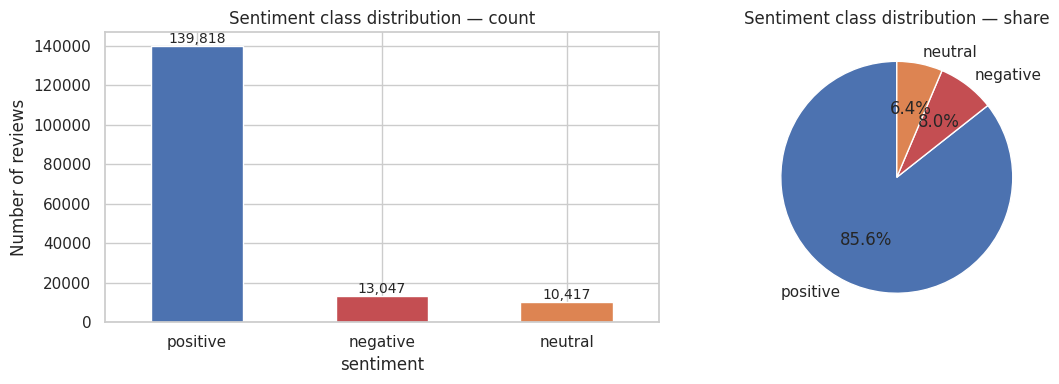

In [35]:
# ── 2. Class distribution ───────────────────────────────────
print("=== SENTIMENT DISTRIBUTION ===")
dist = df["sentiment"].value_counts()
pct  = df["sentiment"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": dist, "percent (%)": pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
dist.plot(kind="bar", ax=axes[0],
          color=["#4C72B0", "#C44E52", "#DD8452"])
axes[0].set_title("Sentiment class distribution — count")
axes[0].set_ylabel("Number of reviews")
axes[0].set_xticklabels(dist.index, rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

# Percentage pie
axes[1].pie(dist, labels=dist.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#C44E52", "#DD8452"],
            startangle=90)
axes[1].set_title("Sentiment class distribution — share")

plt.tight_layout()
plt.show()

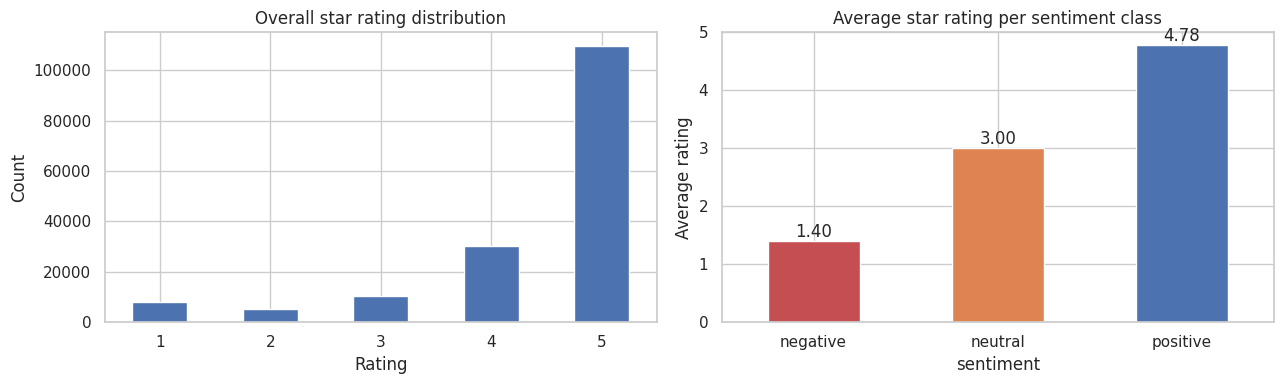

In [36]:
# ── 3. Rating distribution (overall & per sentiment) ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Overall star rating distribution")
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["1", "2", "3", "4", "5"], rotation=0)

# Average rating per sentiment class
df.groupby("sentiment")["rating"].mean().reindex(
    ["negative", "neutral", "positive"]).plot(
    kind="bar", ax=axes[1],
    color=["#C44E52", "#DD8452", "#4C72B0"])
axes[1].set_title("Average star rating per sentiment class")
axes[1].set_ylabel("Average rating")
axes[1].set_xticklabels(["negative", "neutral", "positive"], rotation=0)
axes[1].set_ylim(0, 5)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

plt.tight_layout()
plt.show()

=== SOURCE BREAKDOWN ===
source
amazon_reviews_2023    99906
primary                63376
Name: count, dtype: int64



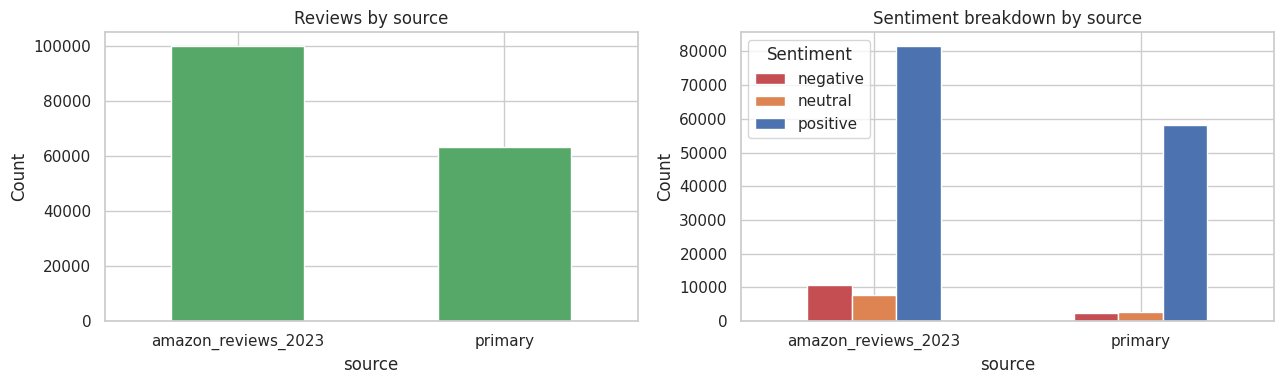

In [37]:
# ── 4. Source breakdown ─────────────────────────────────────
print("=== SOURCE BREAKDOWN ===")
print(df["source"].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["source"].value_counts().plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("Reviews by source")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(df["source"].value_counts().index, rotation=0)

# Sentiment split per source
df.groupby(["source", "sentiment"]).size().unstack(fill_value=0).plot(
    kind="bar", ax=axes[1],
    color=["#C44E52", "#DD8452", "#4C72B0"])
axes[1].set_title("Sentiment breakdown by source")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="Sentiment")

plt.tight_layout()
plt.show()

=== REVIEW LENGTH (words) ===
              count  mean    std  min   25%   50%   75%     max
sentiment                                                      
negative    13047.0  59.6   81.1  1.0  17.0  35.0  70.0  1913.0
neutral     10417.0  76.5  111.3  2.0  19.0  41.0  91.0  3363.0
positive   139818.0  51.4   85.5  1.0  13.0  25.0  55.0  4199.0


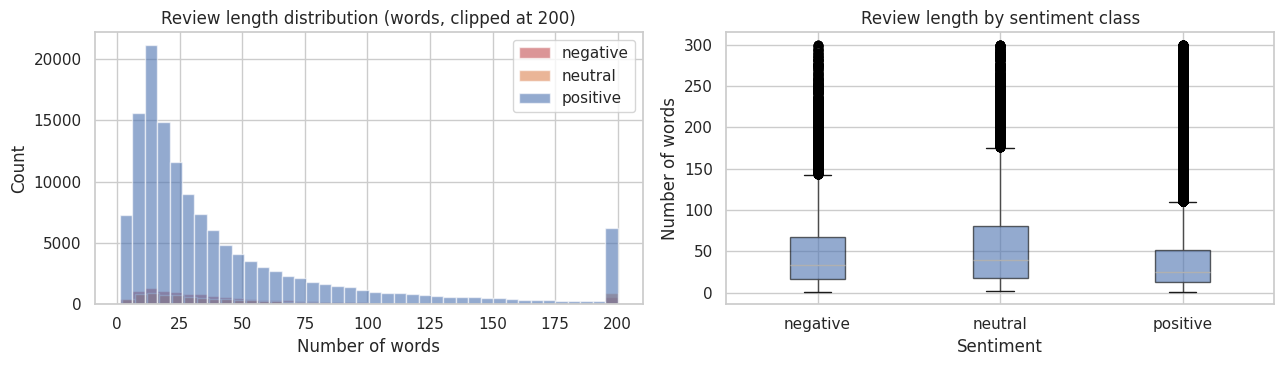

In [38]:
# ── 5. Review length distribution ──────────────────────────
df["review_length"] = df["review_text"].astype(str).str.split().str.len()

print("=== REVIEW LENGTH (words) ===")
print(df.groupby("sentiment")["review_length"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
for label, color in zip(["negative", "neutral", "positive"],
                         ["#C44E52", "#DD8452", "#4C72B0"]):
    sub = df[df["sentiment"] == label]["review_length"]
    axes[0].hist(sub.clip(upper=200), bins=40, alpha=0.6,
                 label=label, color=color)
axes[0].set_title("Review length distribution (words, clipped at 200)")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
df[df["review_length"] <= 300].boxplot(
    column="review_length", by="sentiment",
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6))
axes[1].set_title("Review length by sentiment class")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Number of words")
plt.suptitle("")   # remove auto-title from boxplot

plt.tight_layout()
plt.show()

=== TOP 15 PRODUCTS BY REVIEW COUNT ===
product_name
Fire Tablet, 7 Display, Wi - Fi, 8 GB - Includes Special Offers, Magenta                                    10961
AmazonBasics AAA Performance Alkaline Batteries (36 Count)                                                   7302
Unknown Product                                                                                              6750
Echo (White), Echo (White)                                                                                   3309
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary                               3305
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi - Fi - black     3176
All - New Fire HD 8 Tablet, 8 HD Display, Wi - Fi, 16 GB - Includes Special Offers, Magenta                  2814
Amazon Fire Tv, Amazon Fire Tv                                                                               2527
Fire HD 8 Tablet with Alexa, 8 HD D

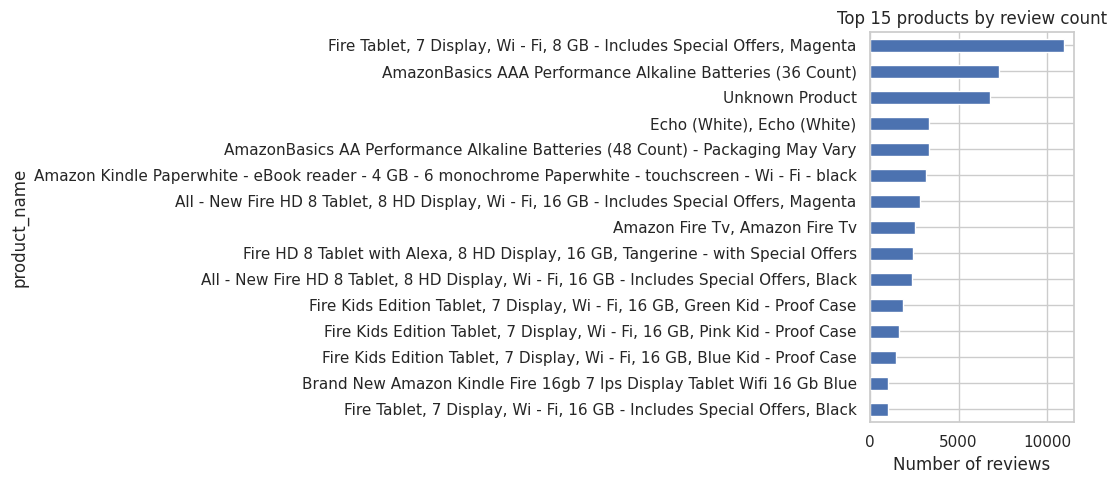

In [39]:
# ── 6. Top products ─────────────────────────────────────────
print("=== TOP 15 PRODUCTS BY REVIEW COUNT ===")
top_products = df["product_name"].value_counts().head(15)
print(top_products)

top_products.plot(kind="barh", figsize=(11, 5), color="#4C72B0")
plt.gca().invert_yaxis()
plt.title("Top 15 products by review count")
plt.xlabel("Number of reviews")
plt.tight_layout()
plt.show()

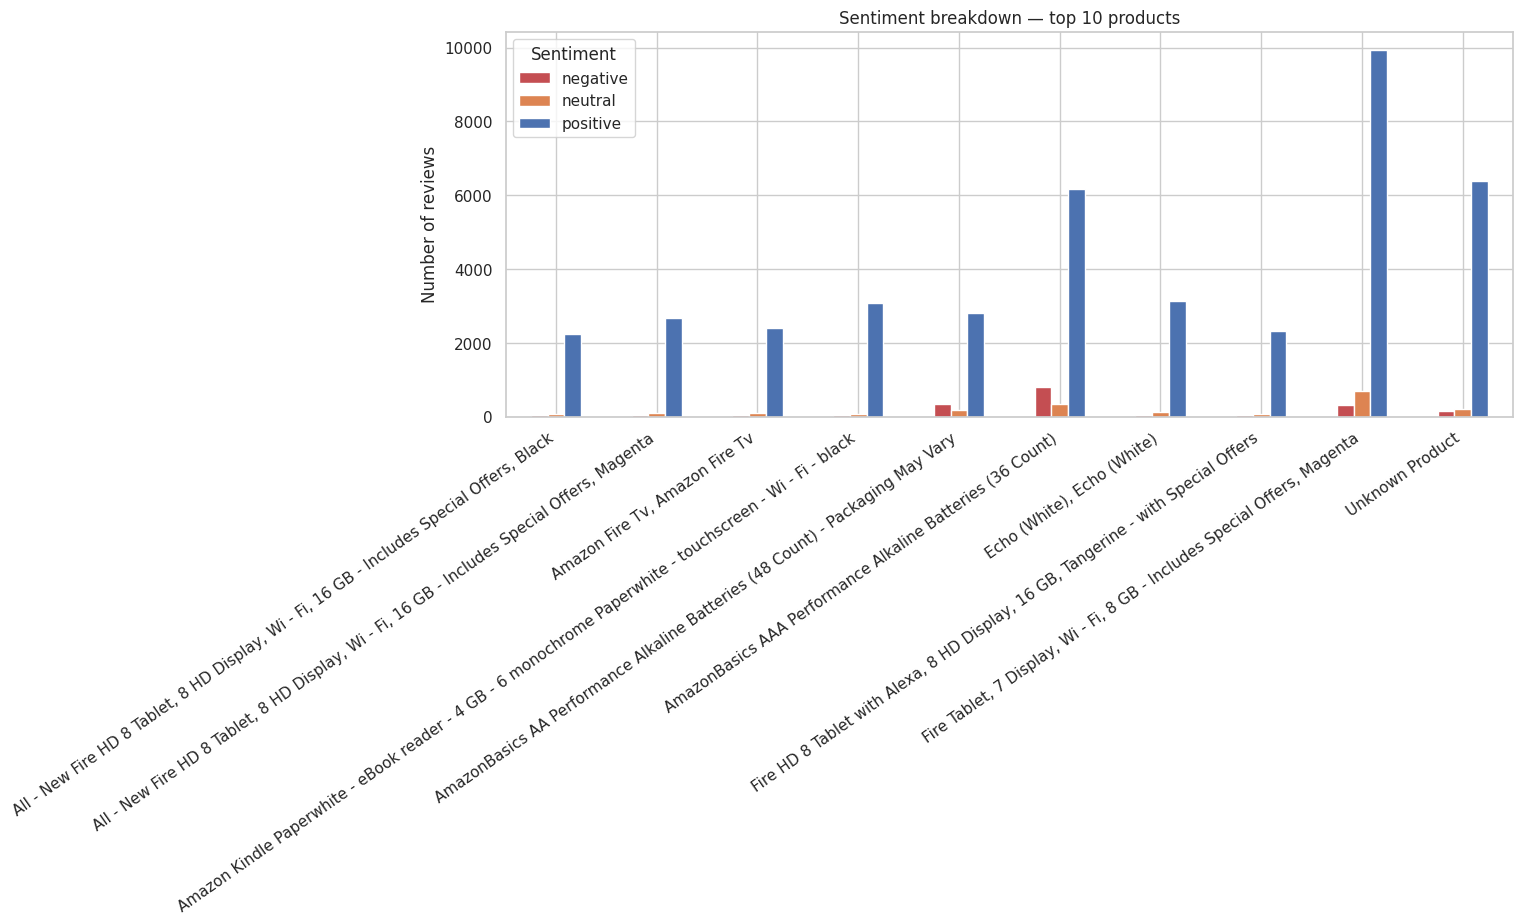

In [40]:
# ── 7. Sentiment per top product ────────────────────────────
top10_names = df["product_name"].value_counts().head(10).index

pivot = (df[df["product_name"].isin(top10_names)]
         .groupby(["product_name", "sentiment"])
         .size()
         .unstack(fill_value=0))

pivot.plot(kind="bar", figsize=(13, 5),
           color=["#C44E52", "#DD8452", "#4C72B0"])
plt.title("Sentiment breakdown — top 10 products")
plt.ylabel("Number of reviews")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

=== TOP 15 RAW CATEGORIES ===
raw_category
Fire Tablets                  24240
AA                            10607
Electronics                    7178
Stereos                        6620
Back To College                5050
Walmart for Business           3470
Books                          3030
Health_and_Household           3030
Home_and_Kitchen               3030
Pet_Supplies                   3030
Clothing_Shoes_and_Jewelry     3030
Musical_Instruments            3030
CDs_and_Vinyl                  3029
Toys_and_Games                 3029
Beauty_and_Personal_Care       3029
Name: count, dtype: int64


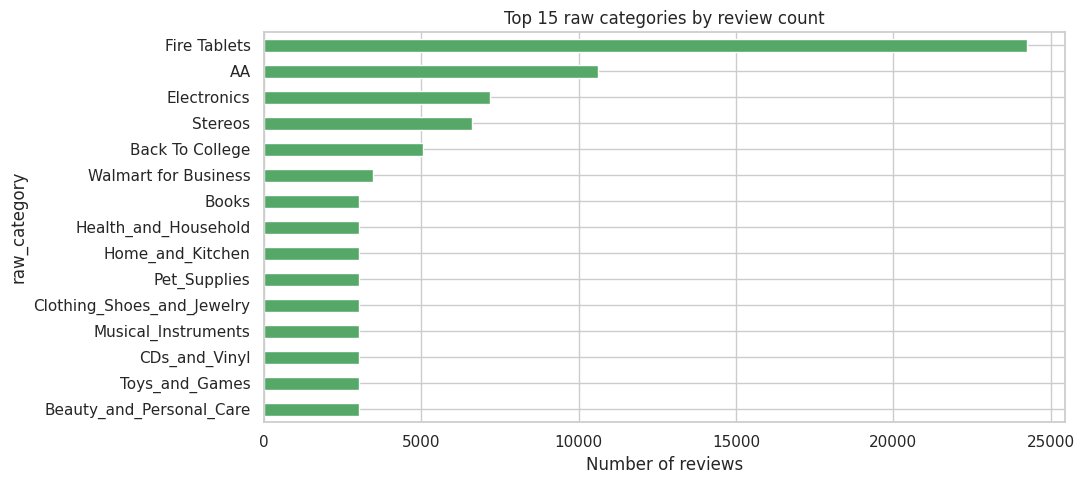

In [41]:
# ── 8. Raw category distribution ───────────────────────────
print("=== TOP 15 RAW CATEGORIES ===")
top_cats = df["raw_category"].value_counts().head(15)
print(top_cats)

top_cats.plot(kind="barh", figsize=(11, 5), color="#55A868")
plt.gca().invert_yaxis()
plt.title("Top 15 raw categories by review count")
plt.xlabel("Number of reviews")
plt.tight_layout()
plt.show()

In [42]:
# ── 9. EDA summary ──────────────────────────────────────────
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total reviews      : {len(df):,}")
print(f"Unique products    : {df['product_name'].nunique():,}")
print(f"Unique categories  : {df['raw_category'].nunique():,}")
print(f"Sources            : {df['source'].unique().tolist()}")
print(f"Avg review length  : {df['review_length'].mean():.1f} words")
print(f"Median length      : {df['review_length'].median():.0f} words")
print()
print("Class balance:")
print(pd.DataFrame({"count": dist, "percent (%)": pct.round(2)}))

EDA SUMMARY
Total reviews      : 163,282
Unique products    : 83,454
Unique categories  : 73
Sources            : ['primary', 'amazon_reviews_2023']
Avg review length  : 53.6 words
Median length      : 27 words

Class balance:
            count  percent (%)
sentiment                     
positive   139818        85.63
negative    13047         7.99
neutral     10417         6.38


**6. BALANCING**

**7. BASELINE MODEL**

**8. COMPARISON MODEL**

**9. EVALUATION**

**10. CLUSTERING**

**11. SUMMARIZATION**

**12. APP**

**13. REPORT + DERIVABLES**